In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Co-ordinate Quantization

We need to take all the the time positions possible, and turn them into integers to be tokenized using quantization.


This is done simply by scaling the numbers knowing their max range and rounding them

In [3]:
import torch

In [12]:
max_seconds = 30
num_tokens = 256


original = torch.rand(1, 1000)*max_seconds
quantized = torch.round(original/max_seconds*num_tokens)
avg_error = torch.mean(torch.abs(original - quantized*max_seconds/num_tokens))
print(avg_error.item()*1000, "ms")

28.956525027751923 ms


# Checking this on real coordinates

~7.5ms error seems fairly reasonable for quantizing into 2048 tokens

Let's see how this looks

In [13]:
from nanodrz.data import gather_speakers_from_folder, artificial_diarisation_sample
from nanodrz import data
from nanodrz.utils import play, visualise_annotation

speakers = data.libritts_test()
len(speakers)

39

21.89825


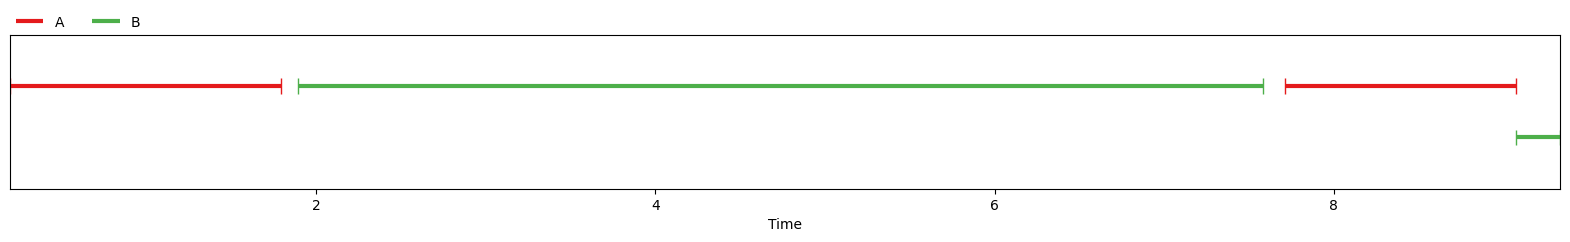

[0.170875, 1.621125, 'A']
[1.8943750000000001, 5.686875, 'B']
[7.712625, 1.363125, 'A']
[9.072375, 6.2001875, 'B']
[15.1335, 1.100125, 'A']
[16.156875, 2.5585, 'B']
[18.6469375, 3.2513125, 'A']


In [14]:
audio, labels = data.artificial_diarisation_sample(speakers, max_secs=30, num_speakers=2,  interrupt_sec_mean=.2, interrupt_var=.5)
print(audio.shape[-1]/16000)
visualise_annotation(labels)
print("\n".join(str(l) for l in labels))
play(audio, 16000)

tensor([[  1.,  14.],
        [ 16.,  49.],
        [ 66.,  12.],
        [ 77.,  53.],
        [129.,   9.],
        [138.,  22.],
        [159.,  28.]])
29.491106048226357 ms
[[0.170875, 1.621125, 'A'], [1.8943750000000001, 5.686875, 'B'], [7.712625, 1.363125, 'A'], [9.072375, 6.2001875, 'B'], [15.1335, 1.100125, 'A'], [16.156875, 2.5585, 'B'], [18.6469375, 3.2513125, 'A']]


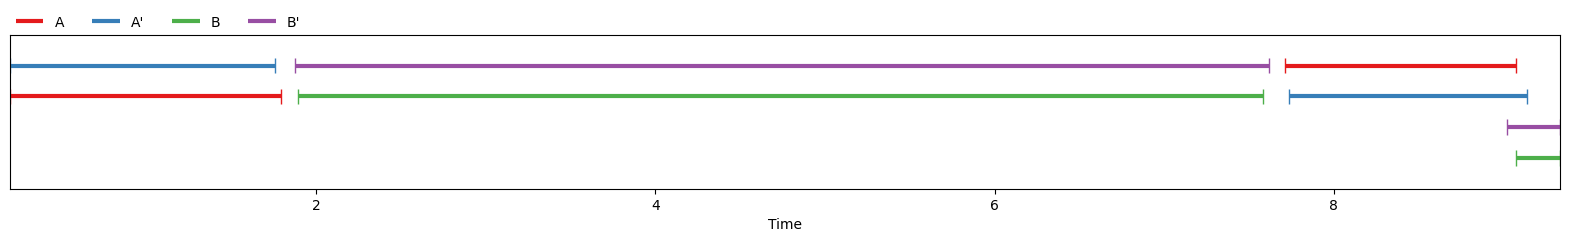

In [15]:
original = torch.tensor([[l[0], l[1]] for l in labels])
quantized = torch.round(original/max_seconds*num_tokens)
print(quantized)
unquantized =  quantized*max_seconds/num_tokens 
avg_error = torch.mean(torch.abs(original - unquantized))
print(avg_error.item()*1000, "ms")

# Visualise these labels

print(labels)
from copy import deepcopy

new_labels = deepcopy(labels)

for i, l in enumerate(new_labels):
    l[0] = unquantized[i][0]
    l[1] = unquantized[i][1]
    l[2] = l[2]+ "'"

# Let's see whether we can see a difference just for good measuer
visualise_annotation(labels+ new_labels)

# Desired Error Loop

Given a tolerable error e, what is the number of tokens we can get away with:

In [18]:
max_seconds = 30
num_tokens = 556

# ms
e = 50

def compute_avg_error(num_tokens, max_seconds):
    original = torch.rand(1, 10000)*max_seconds
    quantized = torch.round(original/max_seconds*num_tokens)
    avg_error = torch.mean(torch.abs(original - quantized*max_seconds/num_tokens))
    avg_error = avg_error.item()*1000
    print(num_tokens, max_seconds, "secs", avg_error, "ms")
    return avg_error
    

avg_error = compute_avg_error(num_tokens, max_seconds)
while avg_error < e:
    num_tokens -= 16
    avg_error = compute_avg_error(num_tokens, max_seconds)

556 30 secs 13.599149882793427 ms
540 30 secs 13.975314795970917 ms
524 30 secs 14.17597010731697 ms
508 30 secs 14.628455974161625 ms
492 30 secs 15.166601166129112 ms
476 30 secs 15.630632638931274 ms
460 30 secs 16.31004549562931 ms
444 30 secs 16.890516504645348 ms
428 30 secs 17.366552725434303 ms
412 30 secs 18.380798399448395 ms
396 30 secs 18.8865028321743 ms
380 30 secs 19.56384815275669 ms
364 30 secs 20.593756809830666 ms
348 30 secs 21.424582228064537 ms
332 30 secs 22.58516661822796 ms
316 30 secs 23.670200258493423 ms
300 30 secs 25.01891367137432 ms
284 30 secs 26.369430124759674 ms
268 30 secs 28.01496349275112 ms
252 30 secs 29.866168275475502 ms
236 30 secs 31.405843794345856 ms
220 30 secs 34.05183553695679 ms
204 30 secs 36.33406385779381 ms
188 30 secs 39.84624519944191 ms
172 30 secs 43.40839758515358 ms
156 30 secs 48.470769077539444 ms
140 30 secs 53.51085215806961 ms
